In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Use a clean plot style
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Load the rollout
data_path = Path('../results/rollouts/cheetah_random_seed0.npz')
data = np.load(data_path, allow_pickle=True)

# Extract arrays
true_obs = data['true_obs']
imagined_obs = data['imagined_obs']
actions = data['actions']
rewards = data['rewards']
metadata = data['metadata'].item()

# Print summary
print('Rollout Summary')
print('=' * 50)
print(f"Task: {metadata['task']}")
print(f"Agent: {metadata['agent_type']}")
print(f"Imagination window: steps {metadata['imagination_start']}-{metadata['imagination_start'] + metadata['horizon']}")
print(f"\nData shapes:")
print(f"  true_obs:      {true_obs.shape}")
print(f"  imagined_obs:  {imagined_obs.shape}")
print(f"  actions:       {actions.shape}")
print(f"  rewards:       {rewards.shape}")
print(f"\nObservation keys: {metadata['obs_keys']}")
print(f"Alignment: {metadata['obs_alignment']}")


Rollout Summary
Task: dmc_cheetah_run
Agent: dreamerv3_random_init
Imagination window: steps 200-400

Data shapes:
  true_obs:      (200, 17)
  imagined_obs:  (200, 17)
  actions:       (200, 6)
  rewards:       (200,)

Observation keys: ('position', 'velocity')
Alignment: true and imagined arrays contain next observations for actions at steps 200-399


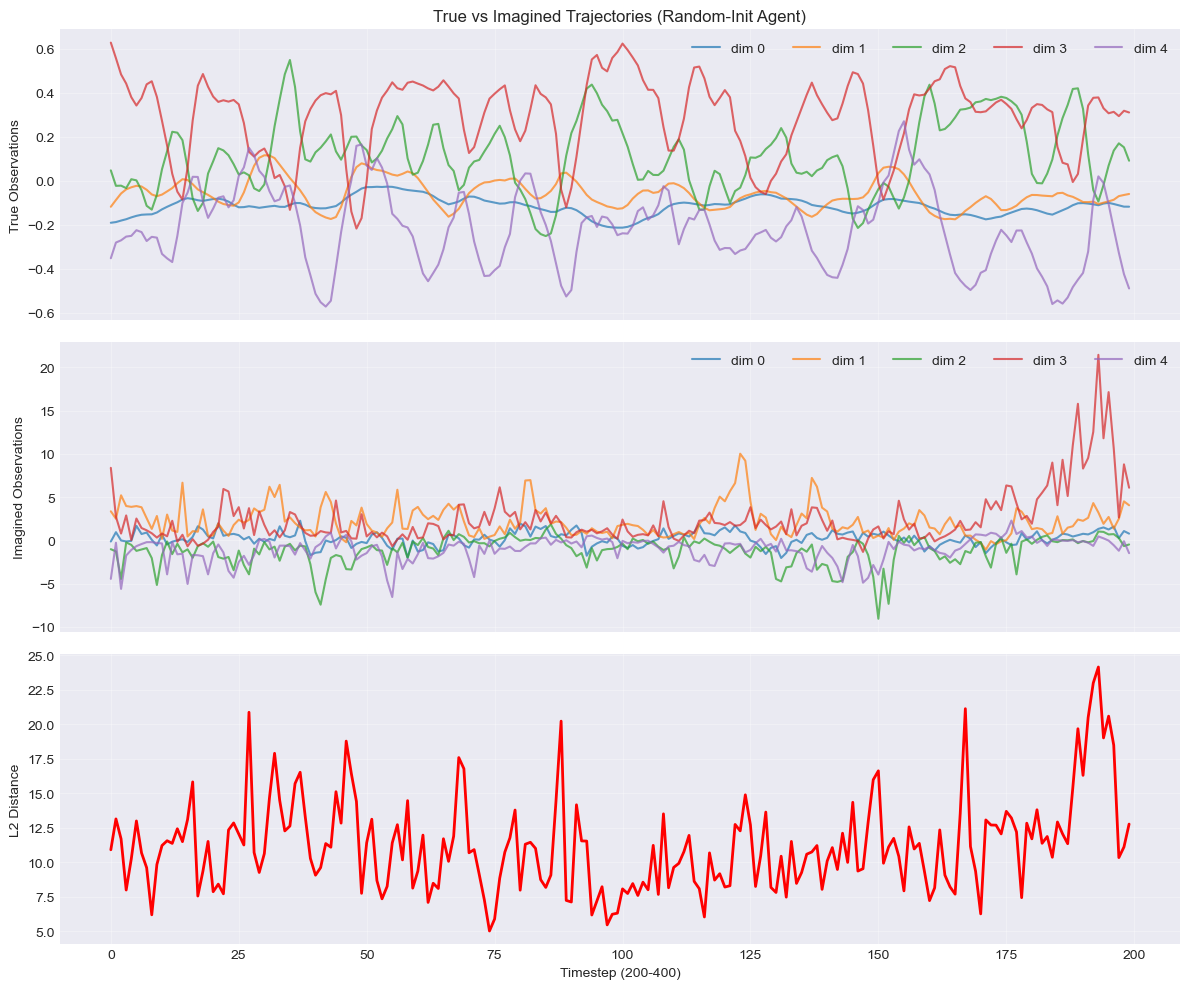


L2 distance stats:
  Mean: 11.2481
  Std:  3.4221
  Max:  24.1548


In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Plot first 5 dimensions of observations
for i in range(min(5, true_obs.shape[1])):
    axes[0].plot(true_obs[:, i], label=f'dim {i}', alpha=0.7, linewidth=1.5)
axes[0].set_ylabel('True Observations')
axes[0].set_title('True vs Imagined Trajectories (Random-Init Agent)')
axes[0].legend(loc='upper right', ncol=5)
axes[0].grid(True, alpha=0.3)

for i in range(min(5, imagined_obs.shape[1])):
    axes[1].plot(imagined_obs[:, i], label=f'dim {i}', alpha=0.7, linewidth=1.5)
axes[1].set_ylabel('Imagined Observations')
axes[1].legend(loc='upper right', ncol=5)
axes[1].grid(True, alpha=0.3)

# Plot L2 distance between true and imagined
l2_dist = np.linalg.norm(true_obs - imagined_obs, axis=1)
axes[2].plot(l2_dist, color='red', linewidth=2)
axes[2].set_ylabel('L2 Distance')
axes[2].set_xlabel('Timestep (200-400)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/rollouts/sanity_check_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nL2 distance stats:")
print(f"  Mean: {l2_dist.mean():.4f}")
print(f"  Std:  {l2_dist.std():.4f}")
print(f"  Max:  {l2_dist.max():.4f}")


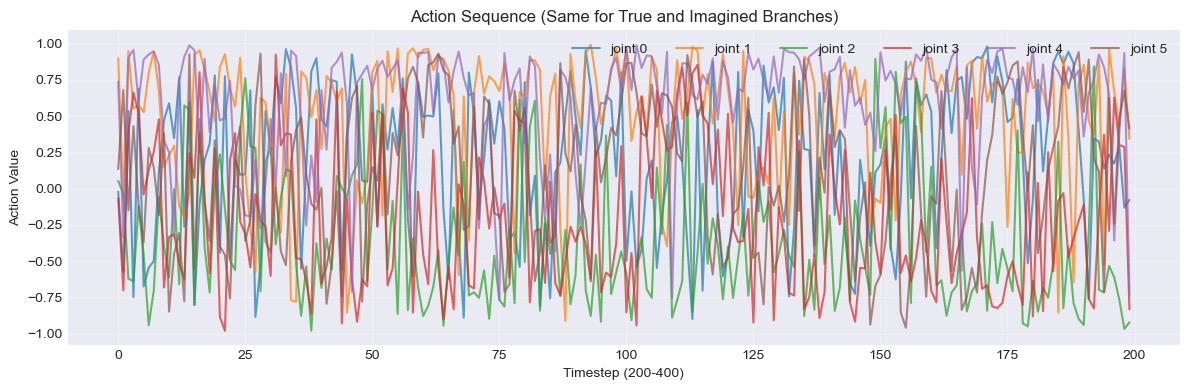

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))

# Plot all action dimensions
for i in range(actions.shape[1]):
    ax.plot(actions[:, i], label=f'joint {i}', alpha=0.7, linewidth=1.5)

ax.set_xlabel('Timestep (200-400)')
ax.set_ylabel('Action Value')
ax.set_title('Action Sequence (Same for True and Imagined Branches)')
ax.legend(loc='upper right', ncol=6)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/rollouts/sanity_check_actions.png', dpi=150, bbox_inches='tight')
plt.show()


## Interpretation

### What we expect (random-init agent):
- ✅ **Data shapes correct**: true_obs and imagined_obs both (200, 17)
- ✅ **Actions aligned**: Same action sequence used for both branches
- ⚠️ **High L2 distance**: Random weights → poor predictions (expected)
- ⚠️ **Divergence over time**: Open-loop imagination drifts without feedback

### What this validates:
1. **Pipeline works**: Environment stepping, RSSM imagination, decoder all functional
2. **Data format correct**: Observations aligned to actions as documented
3. **Ready for real checkpoints**: When we get trained weights, this same pipeline will work

### Next steps (Week 3-4):
- Explore checkpoint sources (r2dreamer, official JAX, Hugging Face)
- OR: Test M5 Pro training feasibility (10k-50k steps)
- Month 2: Run this pipeline with real checkpoints for scientific analysis
